In [ ]:
pip install -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.4 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
VIDEO_PATH = "/content/drive/MyDrive/sample_vocal_tract.mp4"
MODEL_PATH = "/content/drive/MyDrive/sam3.pt"
OUTPUT_DIR = "/content/drive/MyDrive/outputs"

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

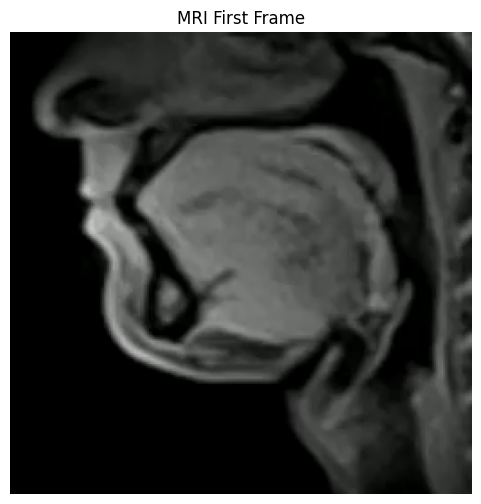

In [ ]:
import cv2
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(VIDEO_PATH)
ok, frame = cap.read()
cap.release()

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(frame_rgb, cmap="gray")
plt.title("MRI First Frame")
plt.axis("off")
plt.show()

In [ ]:
PROMPTS = {
    "tongue": {
        "points": [
            [260, 300],  # center tongue
            [240, 260],  # upper tongue
            [280, 340],  # lower tongue
            [200, 320],  # left edge
            [320, 280],  # right edge
            [180, 200],  # negative (outside)
            [350, 200],  # negative
        ],
        "labels": [1,1,1,1,1,0,0],
        "color": (0, 255, 0),
    },

    "airway": {
        "points": [
            [330, 220],  # airway center
            [350, 260],
            [300, 240],
            [260, 260],  # negative (tongue)
            [400, 200],  # negative
        ],
        "labels": [1,1,1,0,0],
        "color": (255, 255, 0),
    },
}

In [ ]:
from ultralytics.models.sam import SAM3VideoPredictor
from ultralytics import SAM
import numpy as np
import cv2
import imageio
from tqdm import tqdm

# Load models
predictor = SAM3VideoPredictor(overrides=dict(model=MODEL_PATH))
sam_model = SAM(MODEL_PATH)

# Load frames
cap = cv2.VideoCapture(VIDEO_PATH)
fps = cap.get(cv2.CAP_PROP_FPS)
frames = []

while True:
    ok, fr = cap.read()
    if not ok:
        break
    frames.append(fr)
cap.release()

first_frame = frames[0]

def overlay_mask(frame, mask, color):
    out = frame.copy()
    mask = mask.astype(bool)
    color_layer = np.zeros_like(frame, dtype=np.uint8)
    color_layer[:] = color
    out[mask] = cv2.addWeighted(out, 0.6, color_layer, 0.4, 0)[mask]
    return out

def bbox_from_points(points):
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]
    return [min(xs), min(ys), max(xs), max(ys)]

outputs_all = {}

for name, cfg in PROMPTS.items():
    print("Processing:", name)

    # Step 1: segment first frame using points
    results = sam_model.predict(
        source=first_frame,
        points=cfg["points"],
        labels=cfg["labels"],
        verbose=False
    )

    if results[0].masks is None:
        print("No mask found for", name)
        continue

    bbox = bbox_from_points(cfg["points"])

    # Step 2: track over video
    stream = predictor(source=VIDEO_PATH, bboxes=[bbox], stream=True)

    rendered = []

    for i, r in enumerate(tqdm(stream)):
      frame = frames[i].copy()

      if r.masks is not None and len(r.masks.data) > 0:
        mask = r.masks.data[0].cpu().numpy().astype(np.uint8) * 255
        mask = cv2.resize(
            mask,
            (frame.shape[1], frame.shape[0]),
            interpolation=cv2.INTER_NEAREST
        )
        mask = (mask > 127).astype(np.uint8)

        frame = overlay_mask(frame, mask, cfg["color"])

      rendered.append(frame)

    # save video
    out_path = f"{OUTPUT_DIR}/{name}.mp4"
    writer = imageio.get_writer(out_path, fps=max(1,int(fps)), codec="libx264")

    for f in rendered:
        writer.append_data(cv2.cvtColor(f, cv2.COLOR_BGR2RGB))
    writer.close()

    outputs_all[name] = out_path

print("DONE:", outputs_all)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Processing: tongue
WARNING ⚠️ imgsz=[1024] must be multiple of max stride 14, updating to [1036]


0it [00:00, ?it/s]


Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
WARNING ⚠️ imgsz=[640] must be multiple of max stride 14, updating to [644]


/usr/local/lib/python3.12/dist-packages/torch/_inductor/lowering.py:2156: UserWarning: Torchinductor does not support code generation for complex operators. Performance may be worse than eager.
  warnings.warn(
W0318 07:57:29.380000 2576 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


video 1/1 (frame 1/466) /content/drive/MyDrive/sample_vocal_tract.mp4: 644x644 1 0, 42773.0ms


...

video 1/1 (frame 466/466) /content/drive/MyDrive/sample_vocal_tract.mp4: 644x644 1 0, 901.5ms


466it [07:07,  1.09it/s]

Speed: 3.7ms preprocess, 903.4ms inference, 0.9ms postprocess per image at shape (1, 3, 644, 644)
Results saved to /content/runs/segment/predict


466it [07:07,  1.09it/s]


DONE: {'tongue': '/content/drive/MyDrive/outputs/tongue.mp4', 'airway': '/content/drive/MyDrive/outputs/airway.mp4'}
